# $$Formation\ de\ Renforcement\ du\ Secteur\ Technologique$$
# $$(FRST/FDS)$$

## $$Cours\ d'Initiation\ au\ Machine\ Learning$$
### $$Apprentissage\ Non-Supervisé$$

### Professeur : *M. Evens TOUSSAINT*

### Apprenant : *Lionel PETIOTE*

## $$TP\ Final\ ML - NS$$

![Unsupervised Learning](https://tse2.mm.bing.net/th/id/OIP.CD0lIEEEPFWqMRoLIWh0XAHaEK?rs=1&pid=ImgDetMain&o=7&rm=3)

# IMPORTATIONS

In [78]:
# Importation des bibliothèques
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score


# Bibliothèques de visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Gestion d'erreurs
import warnings
warnings.filterwarnings('ignore')

# TRAVAIL DEMANDE

## 1- Chargement et présentation des données

In [4]:
# Chargement des données
from sklearn.datasets import load_wine
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Présentation des données
print(f"Le dataset est composé de {df.shape[0]} observations et de {df.shape[1]} variables.")
print('\nAperçu des données :')
display(df.head())
print('\nRésumé informationnel :\n')
df.info()
print('\nStatistiques descriptives :')
df.describe()

Le dataset est composé de 178 observations et de 13 variables.

Aperçu des données :


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Résumé informationnel :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### $Commentaire$

##### Le jeu de données est composé de 178 enregistrements caractérisés par 13 variables, toutes de type numérique.
- Pas de valeur manquante

##### Les variables présentent des ordres de grandeur très différents. Par exemple :

- Proline peut atteindre des valeurs supérieures à 1000
- Magnesium se situe autour de 100
- Hue varie généralement entre 0 et 2

## 2- Prétraitement et standardisation

##### Une analyse des variables du jeu de données montre une forte disparité dans l’échelle de distribution, ce qui implique que certaines variables ont une variance beaucoup plus élevée que d’autres.
##### Or, les méthodes qu'on aura à utiliser dans cette étude, comme K-Means, DBSCAN ou le clustering agglomératif, reposent sur des mesures de distance (notamment la distance euclidienne).

##### Sans standardisation :
- Les variables à grande échelle (comme Proline) domineraient le calcul des distances
- Les variables à petite échelle (comme Hue) auraient un impact négligeable
- Cela introduirait un biais dans la formation des clusters

##### La standardisation permet :
- d’éliminer l’effet des différences d’échelle entre variables
- d’assurer une contribution équitable de chaque variable
- d’obtenir des résultats de clustering plus fiables et interprétables

In [5]:
# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## 3- Application de K-Means

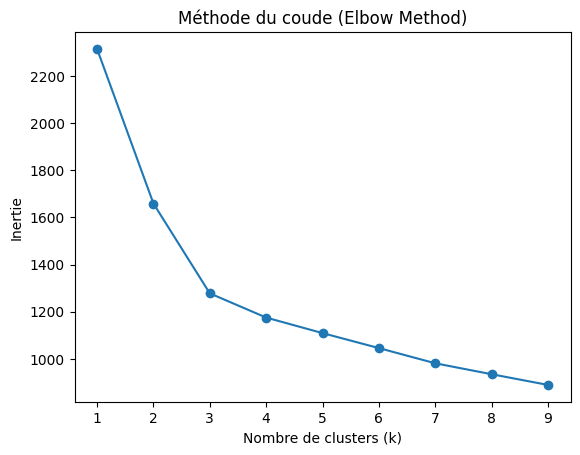

In [12]:
# K-Means
inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Méthode du coude
inertia = []
X = data.data
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Graphique
plt.plot(K_range, inertia, marker='o')
plt.title("Méthode du coude (Elbow Method)")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.show()

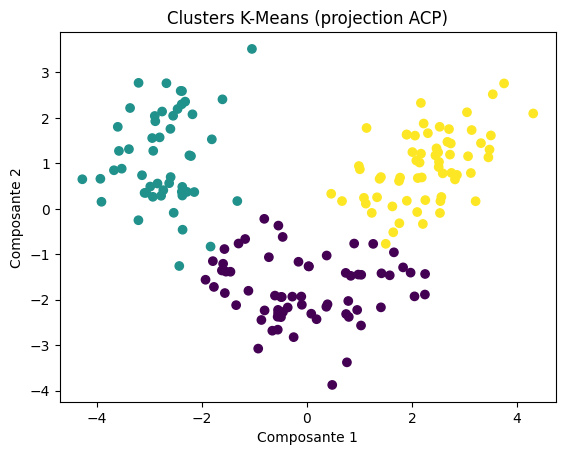

Silhouette score : 0.2848589191898987


In [28]:
# K-Means modelling
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("Clusters K-Means (projection ACP)")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.show()

# Métrique de performance
score = silhouette_score(X_scaled, labels)
print("Silhouette score :", score)

### $Commentaire$

>**Nombre de clusters**

L’algorithme K-Means a été appliqué afin de regrouper les observations en fonction de leur similarité. J'ai testé plusieurs nombres de clusters, allant de 1 à 10 et la méthode du coude a été utilisée pour déterminer le nombre optimal.

L’analyse du graphique montre une diminution significative de l’inertie jusqu’à k = 3, au-delà de laquelle l’amélioration devient marginale. Ainsi, le choix de trois clusters apparaît comme le plus pertinent.

>**Visualisation et interprétation**

Pour afficher le résultat de l'algorithme **K-Means**, on a procédé à une réduction de dimensionnalité des donnée par la méthode de l'ACP en ne gardant que les deux premières composantes principales.

Les résultats obtenus indiquent que les observations sont regroupées en trois classes relativement distinctes.

>**Conclusion du modèle**

Pour le **K-Means**, on obtient un silhouette score de 0.285, ce qui indique une structure de regroupement faible mais non nulle. Les trois types de vins ne sont pas parfaitement séparés dans l'espace des 13 variables chimiques. Cela suggère que K-Means n'est peut-être pas la méthode la plus adaptée à ce jeu de données.

Poursuivons pour une analyse avec DBSCAN.

## 4-  Application de DBSCAN

eps=0.5 ==> clusters=0, bruit=178
eps=1.0 ==> clusters=0, bruit=178
eps=1.5 ==> clusters=0, bruit=178
eps=2.0 ==> clusters=5, bruit=85
eps=2.5 ==> clusters=1, bruit=24
eps=3.0 ==> clusters=1, bruit=11


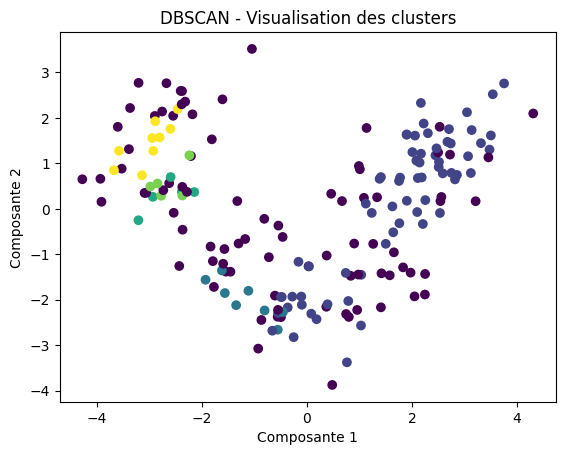

In [55]:
# Choix de rayon de voisinage
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"eps={eps} ==> clusters={n_clusters}, bruit={n_noise}")


# DBSCAN Modelling
dbscan = DBSCAN(eps=2, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)


# Visualisation avec ACP
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_db)
plt.title("DBSCAN - Visualisation des clusters")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.show()


### $Commentaire$
>**Effet des paramètres**

L’algorithme DBSCAN a été appliqué en faisant varier le paramètre eps, qui contrôle la taille du voisinage. Les résultats montrent que :

- Pour des valeurs faibles de eps, un grand nombre d’observations est classé comme bruit (label -1), ce qui traduit une difficulté à identifier des régions suffisamment denses
- Lorsque eps augmente, le nombre de points considérés comme bruit diminue et des clusters plus larges apparaissent
- Pour des valeurs trop élevées de eps, les clusters tendent à fusionner en un seul groupe

Ainsi, le choix des paramètres influence fortement la structure des regroupements obtenus.

>**Identification du bruit**

Dans les résultats obtenus, certaines observations correspondant à des observations situées dans des zones peu denses de l’espace des variables sont associées au label -1, ce qui signifie qu’elles sont considérées comme du bruit.

- Pour un rayon de voisinage fixé à 2 et un nombre minimal de voisin fixé à 5, on obtient 85 points considérés comme bruit.

>**Conclusion de DBSCAN**

DBSCAN présente l’avantage de détecter automatiquement les observations aberrantes, mais son efficacité dépend fortement du choix des paramètres. Dans ce cas, le caractère relativement homogène des densités dans le jeu de données de Wine limite sa capacité à distinguer des clusters pertinents, il apparaît moins performant que K-Means pour identifier des groupes bien distincts sur ce dataset.

## 5- Clustering agglomératif

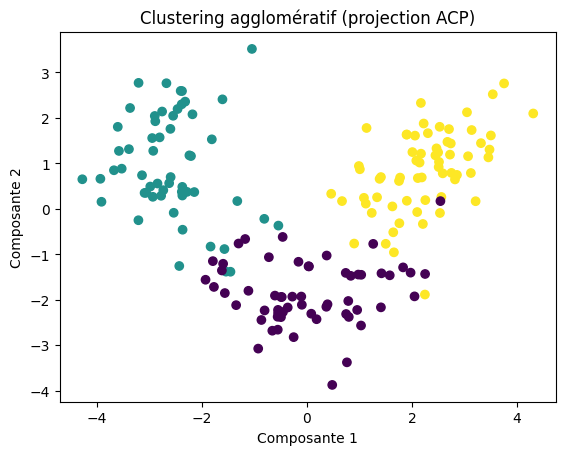


1. Silhouette score: 0.2774


In [66]:
# Clustering agglomératif
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agg = agg.fit_predict(X_scaled)

# Visualisation avec ACP
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_agg)
#plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_agg)
plt.title("Clustering agglomératif (projection ACP)")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.show()

# Evaluation
sil_score = silhouette_score(X_scaled, labels_agg)
print(f"\n1. Silhouette score: {sil_score:.4f}")

## $Commentaire$

L’application du **Clustering agglomératif** avec trois clusters permet d’obtenir des regroupements globalement cohérents. La visualisation dans l’espace des deux premières composantes principales montre une séparation relativement nette entre les groupes, bien que certaines zones présentent des chevauchements.

>**Comparaison avec K-Means et DBSCAN**

- Les clusters obtenus sont presque similaires à ceux identifiés par **K-Means**, ce qui confirme l’existence d’une structure sous-jacente stable dans les données. Cependant, la méthode hiérarchique offre une vision plus progressive de la formation des groupes.

- Contrairement à **DBSCAN**, le clustering agglomératif ne dépend pas d’un seuil de densité et fournit des regroupements plus stables dans le contexte du dataset Wine.

>**Conclusion**

Le clustering agglomératif permet d’identifier des groupes cohérents et confirme les résultats obtenus avec K-Means. Il présente l’avantage de ne pas dépendre d’une initialisation aléatoire et offre une meilleure interprétation de la structure des données. En revanche, il est plus coûteux en calcul. Comparé à DBSCAN, il se montre plus adapté à ce jeu de données, dont la structure ne repose pas sur des variations de densité marquées.

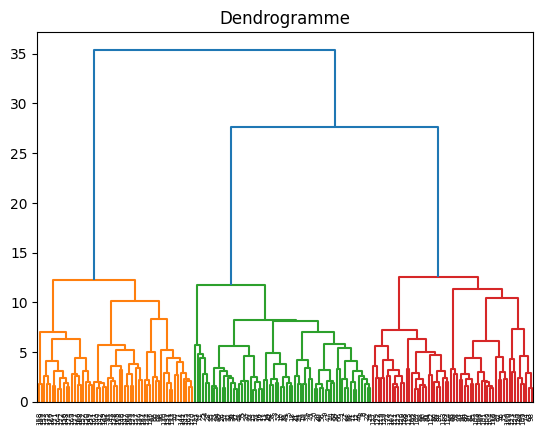

In [63]:
Z = linkage(X_scaled, method='ward')

plt.figure()
dendrogram(Z)
plt.title("Dendrogramme")
plt.show()

## 6- Analyse en composantes principales (ACP)

Variance Expliquée par l'ACP

Composantes principales:
PC1: 36.20% de variance (cumulé: 36.20%)
PC2: 19.21% de variance (cumulé: 55.41%)
PC3: 11.12% de variance (cumulé: 66.53%)
PC4: 7.07% de variance (cumulé: 73.60%)
PC5: 6.56% de variance (cumulé: 80.16%)
PC6: 4.94% de variance (cumulé: 85.10%)
PC7: 4.24% de variance (cumulé: 89.34%)
PC8: 2.68% de variance (cumulé: 92.02%)
PC9: 2.22% de variance (cumulé: 94.24%)
PC10: 1.93% de variance (cumulé: 96.17%)
PC11: 1.74% de variance (cumulé: 97.91%)
PC12: 1.30% de variance (cumulé: 99.20%)
PC13: 0.80% de variance (cumulé: 100.00%)

 Les 2 premières composantes expliquent 55.41% de la variance totale
 Les 3 premières composantes expliquent 66.53% de la variance totale


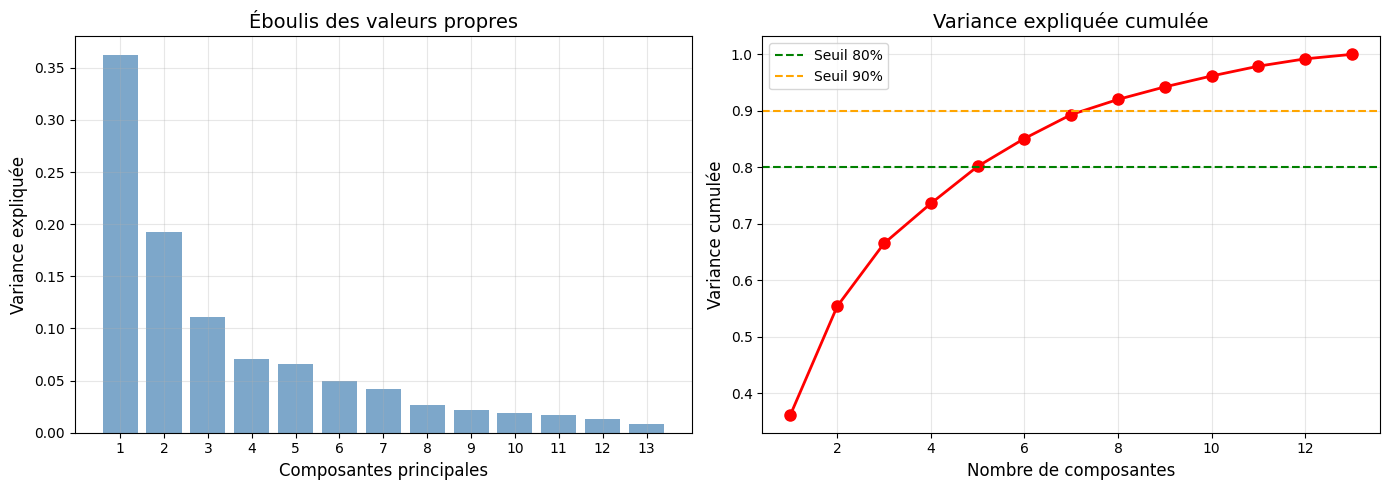

In [82]:
# Application de l'ACP
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Création d'un DataFrame pour les résultats
pca_df = pd.DataFrame(
    X_pca[:, :4],
    columns=[f'PC{i+1}' for i in range(4)]
)

# Calcul des variances expliquées
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Affichage des résultats
print("Variance Expliquée par l'ACP")
print("\nComposantes principales:")
for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance_ratio)):
    print(f"PC{i+1}: {var:.2%} de variance (cumulé: {cum_var:.2%})")

print(f"\n Les 2 premières composantes expliquent {cumulative_variance_ratio[1]:.2%} de la variance totale")
print(f" Les 3 premières composantes expliquent {cumulative_variance_ratio[2]:.2%} de la variance totale")

# Visualisation de la variance expliquée
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1: Variance individuelle (éboulis des valeurs propres)
ax1.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio,
        color='steelblue', alpha=0.7)
ax1.set_xlabel('Composantes principales', fontsize=12)
ax1.set_ylabel('Variance expliquée', fontsize=12)
ax1.set_title('Éboulis des valeurs propres', fontsize=14)
ax1.set_xticks(range(1, len(explained_variance_ratio) + 1))
ax1.grid(True, alpha=0.3)

# Graphique 2: Variance cumulée
ax2.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio,
         'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Nombre de composantes', fontsize=12)
ax2.set_ylabel('Variance cumulée', fontsize=12)
ax2.set_title('Variance expliquée cumulée', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0.8, color='g', linestyle='--', label='Seuil 80%')
ax2.axhline(y=0.9, color='orange', linestyle='--', label='Seuil 90%')
ax2.legend()

plt.tight_layout()
plt.show()

CONTRIBUTION DES VARIABLES AUX COMPOSANTES


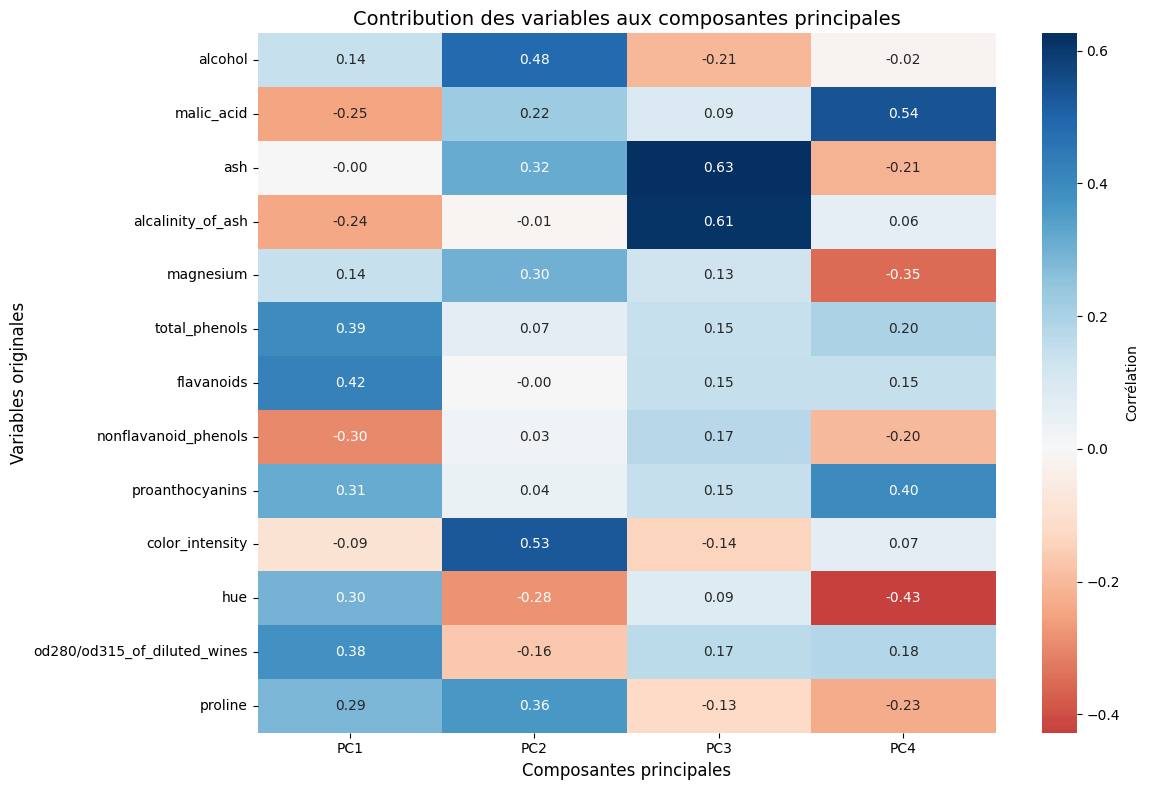


 VARIABLES LES PLUS INFLUENTES PAR COMPOSANTE:

PC1:
  + Forte corrélation positive: flavanoids (0.42), total_phenols (0.39), od280/od315_of_diluted_wines (0.38)
  - Forte corrélation négative: nonflavanoid_phenols (-0.30), malic_acid (-0.25), alcalinity_of_ash (-0.24)

PC2:
  + Forte corrélation positive: color_intensity (0.53), alcohol (0.48), proline (0.36)
  - Forte corrélation négative: hue (-0.28), od280/od315_of_diluted_wines (-0.16), alcalinity_of_ash (-0.01)

PC3:
  + Forte corrélation positive: ash (0.63), alcalinity_of_ash (0.61), nonflavanoid_phenols (0.17)
  - Forte corrélation négative: alcohol (-0.21), color_intensity (-0.14), proline (-0.13)

PC4:
  + Forte corrélation positive: malic_acid (0.54), proanthocyanins (0.40), total_phenols (0.20)
  - Forte corrélation négative: hue (-0.43), magnesium (-0.35), proline (-0.23)


In [76]:
# Matrice des loadings (contribution des variables aux composantes)
loadings = pd.DataFrame(
    pca.components_[:4].T,
    columns=[f'PC{i+1}' for i in range(4)],
    index=df.columns[:-1] if 'target' in df.columns else df.columns
)

print("CONTRIBUTION DES VARIABLES AUX COMPOSANTES")

# Visualisation des loadings (heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0,
            fmt='.2f', cbar_kws={'label': 'Corrélation'})
plt.title('Contribution des variables aux composantes principales', fontsize=14)
plt.xlabel('Composantes principales', fontsize=12)
plt.ylabel('Variables originales', fontsize=12)
plt.tight_layout()
plt.show()

# Identification des variables les plus importantes pour chaque PC
print("\n VARIABLES LES PLUS INFLUENTES PAR COMPOSANTE:")
for pc in range(4):
    print(f"\nPC{pc+1}:")
    # Variables avec contribution positive forte
    positive = loadings.iloc[:, pc].nlargest(3)
    print(f"  + Forte corrélation positive: {', '.join([f'{var} ({val:.2f})' for var, val in positive.items()])}")
    # Variables avec contribution négative forte
    negative = loadings.iloc[:, pc].nsmallest(3)
    print(f"  - Forte corrélation négative: {', '.join([f'{var} ({val:.2f})' for var, val in negative.items()])}")

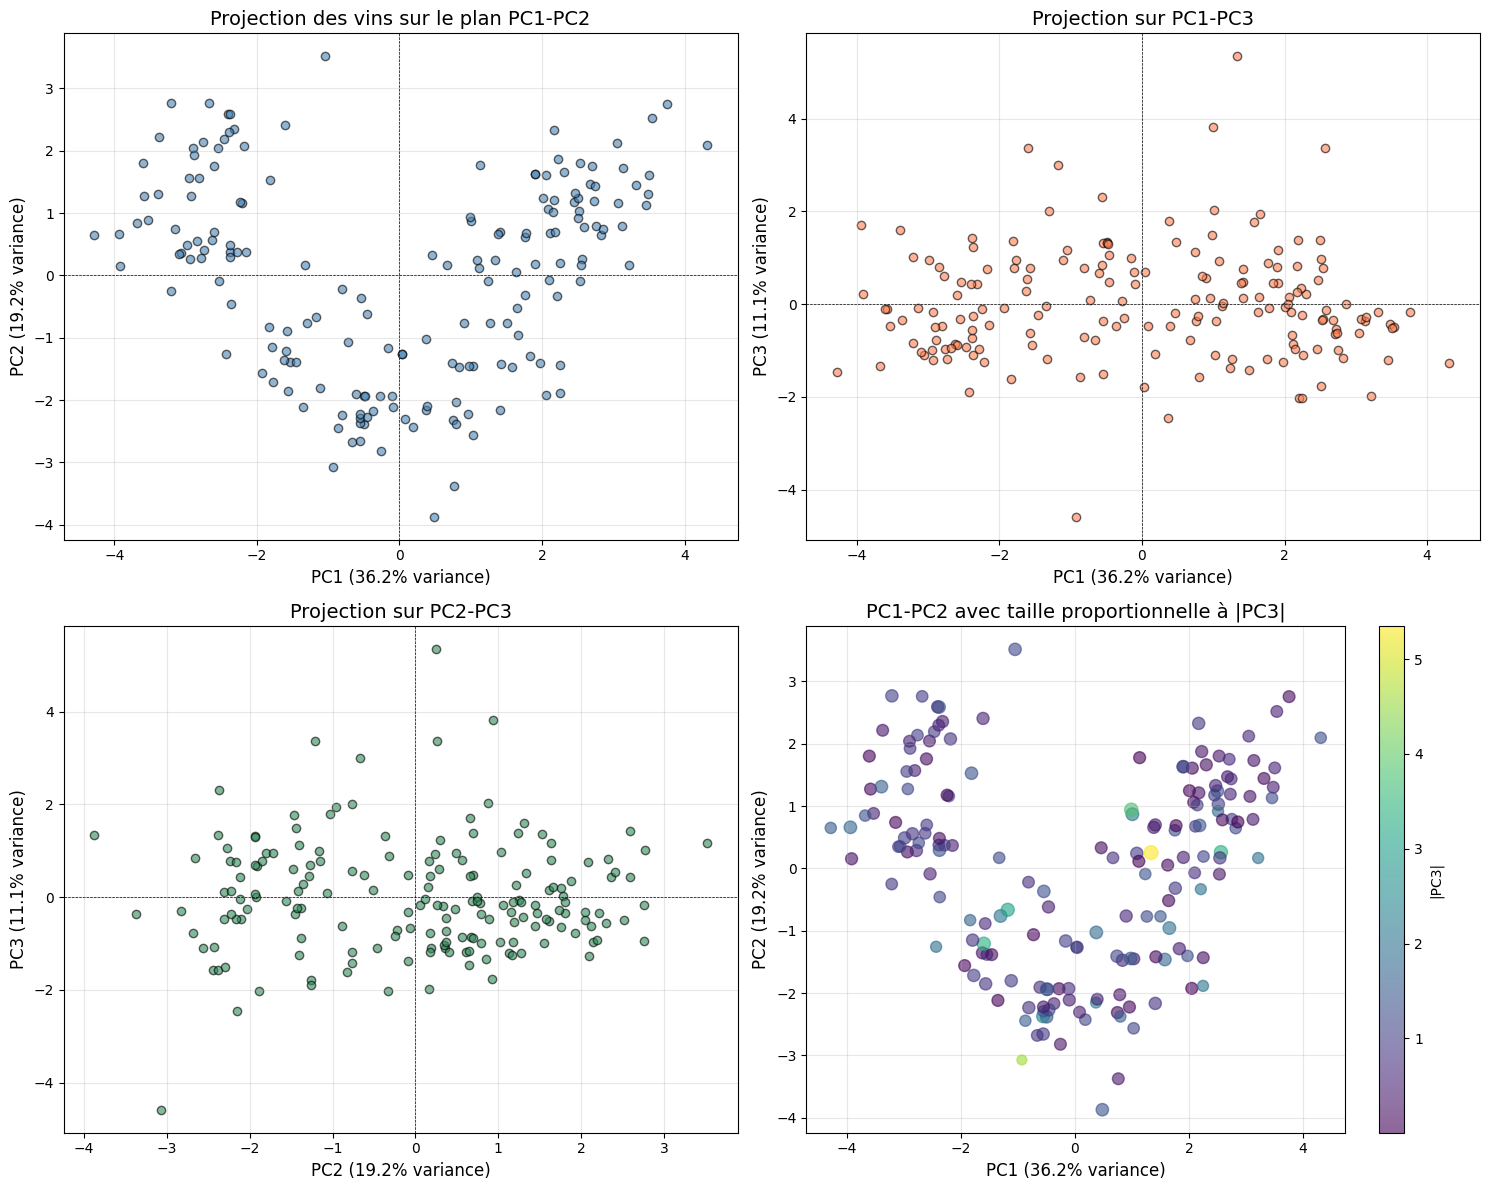

In [77]:
# Visualisation PC1 vs PC2
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Graphique 1: PC1 vs PC2 (sans clusters)
axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, c='steelblue', edgecolors='black')
axes[0, 0].set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)', fontsize=12)
axes[0, 0].set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)', fontsize=12)
axes[0, 0].set_title('Projection des vins sur le plan PC1-PC2', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=0, color='k', linewidth=0.5, linestyle='--')
axes[0, 0].axvline(x=0, color='k', linewidth=0.5, linestyle='--')

# Graphique 2: PC1 vs PC3
axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 2], alpha=0.6, c='coral', edgecolors='black')
axes[0, 1].set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)', fontsize=12)
axes[0, 1].set_ylabel(f'PC3 ({explained_variance_ratio[2]:.1%} variance)', fontsize=12)
axes[0, 1].set_title('Projection sur PC1-PC3', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=0, color='k', linewidth=0.5, linestyle='--')
axes[0, 1].axvline(x=0, color='k', linewidth=0.5, linestyle='--')

# Graphique 3: PC2 vs PC3
axes[1, 0].scatter(X_pca[:, 1], X_pca[:, 2], alpha=0.6, c='seagreen', edgecolors='black')
axes[1, 0].set_xlabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)', fontsize=12)
axes[1, 0].set_ylabel(f'PC3 ({explained_variance_ratio[2]:.1%} variance)', fontsize=12)
axes[1, 0].set_title('Projection sur PC2-PC3', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0, color='k', linewidth=0.5, linestyle='--')
axes[1, 0].axvline(x=0, color='k', linewidth=0.5, linestyle='--')

# Graphique 4: 3D plot (projection 2D de PC1-PC2 avec taille = valeur PC3)
scatter = axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 1],
                             c=np.abs(X_pca[:, 2]),
                             s=50 + 50 * (X_pca[:, 2] - X_pca[:, 2].min()) / (X_pca[:, 2].max() - X_pca[:, 2].min()),
                             alpha=0.6, cmap='viridis')
axes[1, 1].set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)', fontsize=12)
axes[1, 1].set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)', fontsize=12)
axes[1, 1].set_title('PC1-PC2 avec taille proportionnelle à |PC3|', fontsize=14)
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 1], label='|PC3|')

plt.tight_layout()
plt.show()

##  7- Détection d'anomalies avec Isolation Forest

{np.int64(-1): np.int64(9), np.int64(1): np.int64(169)}


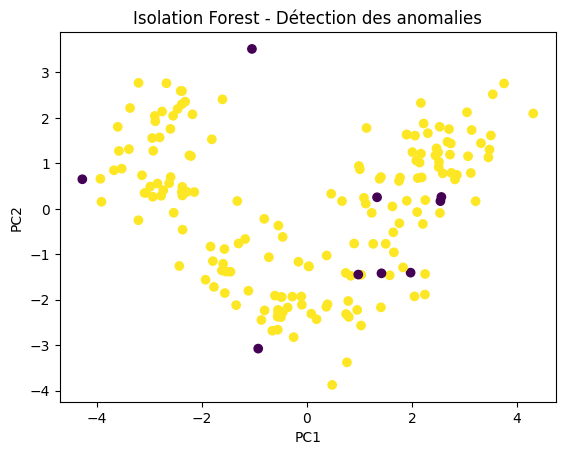

In [81]:
# Modèle
iso = IsolationForest(contamination=0.05, random_state=42)

# Prédiction
labels_iso = iso.fit_predict(X_scaled)

# Résultat
import numpy as np
unique, counts = np.unique(labels_iso, return_counts=True)

print(dict(zip(unique, counts)))



from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_iso)
plt.title("Isolation Forest - Détection des anomalies")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Détection d'anomalies - Isolation Rorest
Points normaux: 169 (94.9%)
Points anormaux: 9 (5.1%)


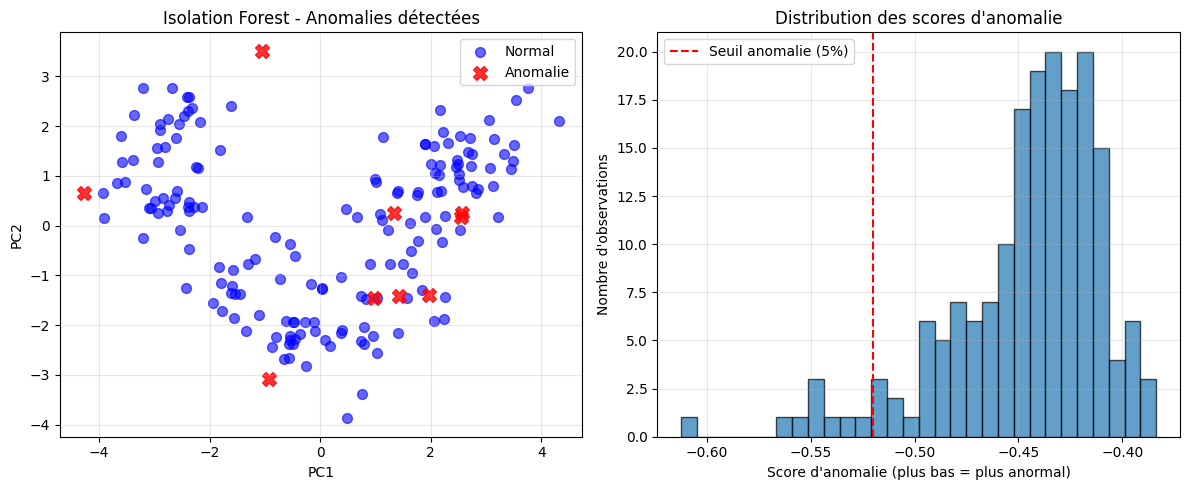

In [85]:
# Application d'Isolation Forest
iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42,
    n_estimators=100
)

# Prédiction des anomalies
anomalies_pred = iso_forest.fit_predict(X_scaled)

# Identification des points anormaux
anomalies = anomalies_pred == -1
normaux = anomalies_pred == 1

# Résultats
print("Détection d'anomalies - Isolation Rorest")
print(f"Points normaux: {sum(normaux)} ({sum(normaux)/len(anomalies_pred):.1%})")
print(f"Points anormaux: {sum(anomalies)} ({sum(anomalies)/len(anomalies_pred):.1%})")

# Visualisation des anomalies
plt.figure(figsize=(12, 5))

# Sous-graphique 1: Points normaux vs anomalies
plt.subplot(1, 2, 1)
plt.scatter(X_pca[normaux, 0], X_pca[normaux, 1],
            c='blue', label='Normal', alpha=0.6, s=50)
plt.scatter(X_pca[anomalies, 0], X_pca[anomalies, 1],
            c='red', label='Anomalie', alpha=0.8, s=100, marker='X')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Isolation Forest - Anomalies détectées')
plt.legend()
plt.grid(True, alpha=0.3)

# Sous-graphique 2: Score d'anomalie
plt.subplot(1, 2, 2)
scores = iso_forest.score_samples(X_scaled)
plt.hist(scores, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=np.percentile(scores, 5), color='red',
            linestyle='--', label='Seuil anomalie (5%)')
plt.xlabel('Score d\'anomalie (plus bas = plus anormal)')
plt.ylabel('Nombre d\'observations')
plt.title('Distribution des scores d\'anomalie')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

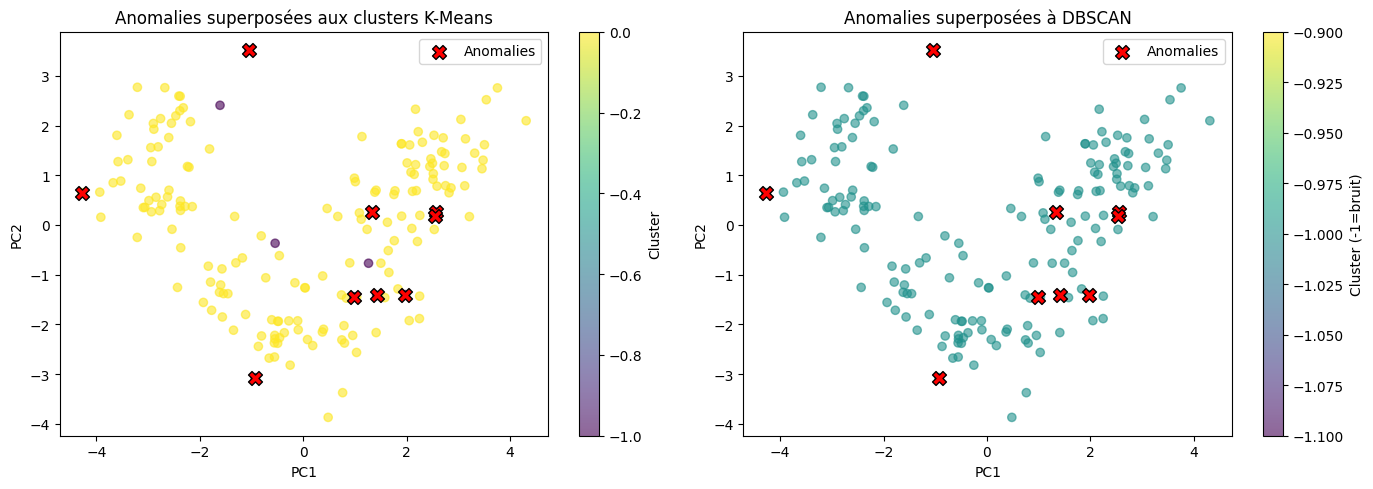

In [87]:
# Comparaison anomalies vs clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avec K-Means
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=labels, cmap='viridis', alpha=0.6)
# Surligner les anomalies
axes[0].scatter(X_pca[anomalies, 0], X_pca[anomalies, 1],
                c='red', s=100, marker='X', edgecolors='black',
                label='Anomalies')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Anomalies superposées aux clusters K-Means')
axes[0].legend()
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Avec DBSCAN
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=4)
labels_dbscan = dbscan.fit_predict(X_scaled)

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=labels_dbscan, cmap='viridis', alpha=0.6)
axes[1].scatter(X_pca[anomalies, 0], X_pca[anomalies, 1],
                c='red', s=100, marker='X', edgecolors='black',
                label='Anomalies')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Anomalies superposées à DBSCAN')
axes[1].legend()
plt.colorbar(scatter2, ax=axes[1], label='Cluster (-1=bruit)')

plt.tight_layout()
plt.show()

[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


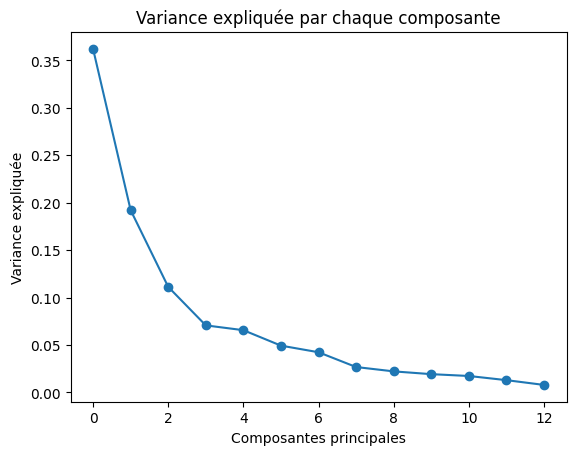

In [67]:
# ACP
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variance expliquée
variance_expliquee = pca.explained_variance_ratio_

print(variance_expliquee)

# Graphiques
plt.plot(variance_expliquee, marker='o')
plt.title("Variance expliquée par chaque composante")
plt.xlabel("Composantes principales")
plt.ylabel("Variance expliquée")
plt.show()

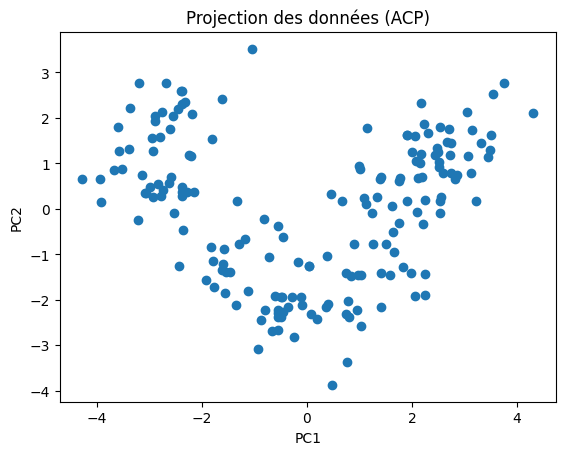

In [68]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

plt.scatter(X_pca2[:,0], X_pca2[:,1])
plt.title("Projection des données (ACP)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()